In [28]:
"""
Exercice 1 : Simulation des données utilisateur
Génère des profils avec distribution normale + valeurs manquantes + valeurs aberrantes.
"""

import numpy as np
import json
import random

np.random.seed(41)
random.seed(41)

GENRES = ["action", "drame", "comédie", "thriller", "sci-fi", "horreur", "romance", "animation"]

FILMS = [
    {"movie": "Inception",       "genre": "sci-fi",    "director": "Nolan"},
    {"movie": "Interstellar",    "genre": "sci-fi",    "director": "Nolan"},
    {"movie": "The Dark Knight", "genre": "action",    "director": "Nolan"},
    {"movie": "Parasite",        "genre": "thriller",  "director": "Bong"},
    {"movie": "Joker",           "genre": "drame",     "director": "Phillips"},
    {"movie": "Avengers",        "genre": "action",    "director": "Russo"},
    {"movie": "Get Out",         "genre": "horreur",   "director": "Peele"},
    {"movie": "La La Land",      "genre": "romance",   "director": "Chazelle"},
    {"movie": "Toy Story",       "genre": "animation", "director": "Lasseter"},
    {"movie": "The Hangover",    "genre": "comédie",   "director": "Phillips"},
    {"movie": "Mad Max",         "genre": "action",    "director": "Miller"},
    {"movie": "Her",             "genre": "sci-fi",    "director": "Jonze"},
    {"movie": "Midsommar",       "genre": "horreur",   "director": "Aster"},
    {"movie": "The Notebook",    "genre": "romance",   "director": "Cassavetes"},
    {"movie": "Superbad",        "genre": "comédie",   "director": "Mottola"},
]

PRENOMS = ["Alice", "Bob", "Clara", "David", "Eva", "Fatou", "Georges", "Hana",
           "Ibra", "Julia", "Kevin", "Laure", "Marc", "Nina", "Omar"]


# ── Génération des préférences (distribution normale) ─────────────────────────
def generer_preferences(n_genres: int = 2) -> list:
    centre = np.random.randint(0, len(GENRES))
    indices = np.random.normal(loc=centre, scale=2, size=30).astype(int)
    indices = np.clip(indices, 0, len(GENRES) - 1)
    unique, counts = np.unique(indices, return_counts=True)
    top = unique[np.argsort(-counts)][:n_genres]
    return [GENRES[i] for i in top]


# ── Génération de l'historique de visionnage ──────────────────────────────────
def generer_historique(preferences: list, n_films: int = 5) -> list:
    films_pref   = [f for f in FILMS if f["genre"] in preferences]
    films_autres = [f for f in FILMS if f["genre"] not in preferences]

    historique = []
    for _ in range(n_films):
        if films_pref and random.random() < 0.7:
            film = random.choice(films_pref)
            note = int(np.clip(np.random.normal(4, 0.8), 1, 5))
        elif films_autres:
            film = random.choice(films_autres)
            note = int(np.clip(np.random.normal(2.5, 1), 1, 5))
        else:
            break

        historique.append({
            "movie":    film["movie"],
            "genre":    film["genre"],
            "director": film["director"],
            "rating":   note,
        })
    return historique


# ── Injection de valeurs manquantes ───────────────────────────────────────────
def injecter_manquants(utilisateur: dict, proba: float = 0.25) -> dict:
    """
    Supprime aléatoirement certains champs pour simuler des données incomplètes.
    Champs ciblés : age, preferences, rating ou director dans l'historique.
    """
    # Âge manquant
    if random.random() < proba:
        utilisateur["age"] = None          # valeur manquante explicite

    # Champs manquants dans l'historique
    for h in utilisateur["watch_history"]:
        if random.random() < proba:
            h["rating"] = None             # note non renseignée
        if random.random() < proba:
            h["director"] = None           # réalisateur non renseigné

    return utilisateur


# ── Injection de valeurs aberrantes ───────────────────────────────────────────
def injecter_aberrants(utilisateur: dict, proba: float = 0.20) -> dict:
    """
    Introduit des valeurs hors domaine pour simuler des erreurs de saisie.
    - Âge : valeur négative ou extrêmement élevée
    - Note : hors de [1, 5]
    - Genre : valeur inconnue
    """
    ABERRANTS_AGE   = [-5, 0, 150, 999]
    ABERRANTS_NOTES = [-1, 0, 6, 10, 99]
    ABERRANTS_GENRE = ["inconnu", "???", "", "N/A"]

    # Âge aberrant
    if utilisateur["age"] is not None and random.random() < proba:
        utilisateur["age"] = random.choice(ABERRANTS_AGE)

    # Note ou genre aberrant dans l'historique
    for h in utilisateur["watch_history"]:
        if h["rating"] is not None and random.random() < proba:
            h["rating"] = random.choice(ABERRANTS_NOTES)
        if random.random() < proba:
            h["genre"] = random.choice(ABERRANTS_GENRE)

    return utilisateur


# ── Création d'un utilisateur complet ─────────────────────────────────────────
def creer_utilisateur(nom: str) -> dict:
    age         = int(np.clip(np.random.normal(30, 10), 15, 70))
    preferences = generer_preferences(n_genres=random.randint(2, 3))
    historique  = generer_historique(preferences, n_films=random.randint(4, 7))

    utilisateur = {
        "name":          nom,
        "age":           age,
        "preferences":   preferences,
        "watch_history": historique,
    }

    # Injection des anomalies
    utilisateur = injecter_manquants(utilisateur, proba=0.05)
    utilisateur = injecter_aberrants(utilisateur, proba=0.05)

    return utilisateur


def generer_dataset(n_users: int = 10) -> list:
    return [creer_utilisateur(PRENOMS[i % len(PRENOMS)]) for i in range(n_users)]


# ── Rapport de qualité des données ────────────────────────────────────────────
def rapport_qualite(utilisateurs: list):
    total_users  = len(utilisateurs)
    age_manquant = sum(1 for u in utilisateurs if u["age"] is None)

    total_films    = sum(len(u["watch_history"]) for u in utilisateurs)
    notes_manquantes = sum(
        1 for u in utilisateurs for h in u["watch_history"] if h["rating"] is None
    )
    notes_aberrantes = sum(
        1 for u in utilisateurs for h in u["watch_history"]
        if h["rating"] is not None and not (1 <= h["rating"] <= 5)
    )
    ages_aberrants = sum(
        1 for u in utilisateurs
        if u["age"] is not None and not (10 <= u["age"] <= 120)
    )
    genres_aberrants = sum(
        1 for u in utilisateurs for h in u["watch_history"]
        if h["genre"] not in GENRES
    )

    print("\n" + "═" * 50)
    print("  RAPPORT QUALITÉ DES DONNÉES")
    print("═" * 50)
    print(f"  Utilisateurs générés       : {total_users}")
    print(f"  ── Âge manquant (None)     : {age_manquant}  ({age_manquant/total_users*100:.0f}%)")
    print(f"  ── Âge aberrant            : {ages_aberrants}")
    print(f"\n  Films dans l'historique    : {total_films}")
    print(f"  ── Notes manquantes        : {notes_manquantes}  ({notes_manquantes/total_films*100:.0f}%)")
    print(f"  ── Notes aberrantes        : {notes_aberrantes}  ({notes_aberrantes/total_films*100:.0f}%)")
    print(f"  ── Genres aberrants        : {genres_aberrants}")
    print("═" * 50)


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    utilisateurs = generer_dataset(n_users=10)

    # Affichage détaillé
    for u in utilisateurs:
        age_str  = str(u["age"]) if u["age"] is not None else "?? manquant"
        pref_str = str(u["preferences"]) if u["preferences"] else "?? manquant"
        print(f"\n👤 {u['name']} | âge : {age_str} | Préférences : {pref_str}")
        for h in u["watch_history"]:
            note_str = f"{h['rating']}/5" if h["rating"] is not None else "??"
            dir_str  = h["director"] if h["director"] else "??"
            flag     = "  ABERRANT" if (
                h["rating"] is not None and not (1 <= h["rating"] <= 5)
                or h["genre"] not in GENRES
            ) else ""
            print(f"    {h['movie']} | genre:{h['genre']} | réal:{dir_str} | note:{note_str}{flag}")

    # Rapport qualité
    rapport_qualite(utilisateurs)

    # Sauvegarde
    with open("utilisateurs.json", "w", encoding="utf-8") as f:
        json.dump(utilisateurs, f, ensure_ascii=False, indent=2)
    print("\n Données sauvegardées dans utilisateurs.json")


👤 Alice | âge : 27 | Préférences : ['animation', 'horreur', 'thriller']
    Get Out | genre:horreur | réal:Peele | note:3/5
    The Hangover | genre:comédie | réal:Phillips | note:3/5
    Toy Story | genre:animation | réal:Lasseter | note:4/5
    Midsommar | genre:horreur | réal:Aster | note:4/5
    The Notebook | genre:romance | réal:Cassavetes | note:1/5
    Get Out | genre:horreur | réal:Peele | note:??

👤 Bob | âge : ?? manquant | Préférences : ['action', 'thriller']
    The Dark Knight | genre:inconnu | réal:Nolan | note:4/5  ABERRANT
    Parasite | genre:thriller | réal:Bong | note:3/5
    The Dark Knight | genre:action | réal:Nolan | note:4/5
    Mad Max | genre:action | réal:Miller | note:5/5
    Get Out | genre:horreur | réal:Peele | note:2/5

👤 Clara | âge : 38 | Préférences : ['action', 'comédie']
    The Hangover | genre:comédie | réal:Phillips | note:3/5
    Toy Story | genre:animation | réal:Lasseter | note:1/5
    Interstellar | genre:sci-fi | réal:Nolan | note:3/5
    

In [ ]:
"""
Exercice 2 : Moteur de recommandation
- Filtrage par préférences
- Corrélation de Pearson (scipy.stats.pearsonr)
- Clustering K-Means (sklearn.cluster.KMeans)
"""

import json
import numpy as np
from scipy.stats import pearsonr
from sklearn.cluster import KMeans

# ── Catalogue complet ──────────────────────────────────────────────────────────
CATALOGUE = [
    {"movie": "Inception",       "genre": "sci-fi",    "director": "Nolan",      "avg_rating": 4.8},
    {"movie": "Interstellar",    "genre": "sci-fi",    "director": "Nolan",      "avg_rating": 4.7},
    {"movie": "The Dark Knight", "genre": "action",    "director": "Nolan",      "avg_rating": 4.9},
    {"movie": "Parasite",        "genre": "thriller",  "director": "Bong",       "avg_rating": 4.6},
    {"movie": "Joker",           "genre": "drame",     "director": "Phillips",   "avg_rating": 4.3},
    {"movie": "Avengers",        "genre": "action",    "director": "Russo",      "avg_rating": 4.2},
    {"movie": "Get Out",         "genre": "horreur",   "director": "Peele",      "avg_rating": 4.4},
    {"movie": "La La Land",      "genre": "romance",   "director": "Chazelle",   "avg_rating": 4.1},
    {"movie": "Toy Story",       "genre": "animation", "director": "Lasseter",   "avg_rating": 4.5},
    {"movie": "The Hangover",    "genre": "comédie",   "director": "Phillips",   "avg_rating": 3.9},
    {"movie": "Mad Max",         "genre": "action",    "director": "Miller",     "avg_rating": 4.3},
    {"movie": "Her",             "genre": "sci-fi",    "director": "Jonze",      "avg_rating": 4.4},
    {"movie": "Midsommar",       "genre": "horreur",   "director": "Aster",      "avg_rating": 4.0},
    {"movie": "The Notebook",    "genre": "romance",   "director": "Cassavetes", "avg_rating": 3.8},
    {"movie": "Superbad",        "genre": "comédie",   "director": "Mottola",    "avg_rating": 3.7},
    {"movie": "Arrival",         "genre": "sci-fi",    "director": "Villeneuve", "avg_rating": 4.6},
    {"movie": "John Wick",       "genre": "action",    "director": "Stahelski",  "avg_rating": 4.3},
    {"movie": "The Shining",     "genre": "horreur",   "director": "Kubrick",    "avg_rating": 4.7},
]

GENRES = ["action", "drame", "comédie", "thriller", "sci-fi", "horreur", "romance", "animation"]


# ── 1. Filtrage par préférences ────────────────────────────────────────────────
def recommander_par_preference(utilisateur: dict, top_n: int = 3) -> list[dict]:
    """Retourne les films du catalogue correspondant aux genres aimés, non encore vus."""
    vus = {h["movie"] for h in utilisateur["watch_history"]}
    prefs = utilisateur["preferences"] or []   # None → liste vide

    candidats = [
        f for f in CATALOGUE
        if f["genre"] in prefs and f["movie"] not in vus
    ]
    # Tri par note moyenne décroissante
    candidats.sort(key=lambda x: x["avg_rating"], reverse=True)
    return candidats[:top_n]


# ── 2. Corrélation de Pearson entre utilisateurs ───────────────────────────────
def vecteur_notes(utilisateur: dict) -> np.ndarray:
    """Vecteur de notes par genre (moyenne, 0 si non vu ou note manquante/aberrante)."""
    notes = {g: [] for g in GENRES}
    for h in utilisateur["watch_history"]:
        # Ignorer notes manquantes ou aberrantes
        if h["rating"] is None or not (1 <= h["rating"] <= 5):
            continue
        if h["genre"] in notes:
            notes[h["genre"]].append(h["rating"])
    return np.array([np.mean(v) if v else 0 for v in notes.values()])


def utilisateur_similaire(cible: dict, tous: list[dict]) -> dict | None:
    """Trouve l'utilisateur le plus similaire via corrélation de Pearson."""
    vec_cible = vecteur_notes(cible)
    meilleur, meilleur_r = None, -2

    for u in tous:
        if u["name"] == cible["name"]:
            continue
        vec_u = vecteur_notes(u)
        # Pearson nécessite une variance non nulle
        if vec_cible.std() == 0 or vec_u.std() == 0:
            continue
        r, _ = pearsonr(vec_cible, vec_u)
        if r > meilleur_r:
            meilleur_r, meilleur = r, u

    return meilleur, meilleur_r


def recommander_par_pearson(cible: dict, tous: list[dict], top_n: int = 3) -> list[dict]:
    """Recommande les films les mieux notés par l'utilisateur le plus similaire."""
    similaire, r = utilisateur_similaire(cible, tous)
    if similaire is None:
        return []

    print(f"   → Utilisateur similaire : {similaire['name']} (r = {r:.2f})")
    vus = {h["movie"] for h in cible["watch_history"]}

    candidats = [
        h for h in similaire["watch_history"]
        if h["movie"] not in vus
        and h["rating"] is not None
        and 1 <= h["rating"] <= 5
        and h["rating"] >= 4
    ]
    candidats.sort(key=lambda x: x["rating"], reverse=True)
    return candidats[:top_n]


# ── 3. Clustering K-Means ─────────────────────────────────────────────────────
def clustering_kmeans(tous: list[dict], k: int = 3):
    """nous regroupons maintenant les utilisateurs par profil de genre via K-Means (sklearn)."""
    vecteurs = np.array([vecteur_notes(u) for u in tous], dtype=float)

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(vecteurs)

    groupes = {i: [] for i in range(k)}
    for idx, label in enumerate(labels):
        groupes[label].append(tous[idx])

    return groupes


def recommander_par_cluster(cible: dict, tous: list[dict], top_n: int = 3) -> list[dict]:
    """Recommande les films les mieux notés dans le même cluster."""
    groupes = clustering_kmeans(tous)
    vus = {h["movie"] for h in cible["watch_history"]}

    # Trouver le groupe de l'utilisateur cible
    for groupe in groupes.values():
        noms = [u["name"] for u in groupe]
        if cible["name"] in noms:
            membres = [u for u in groupe if u["name"] != cible["name"]]
            break
    else:
        return []

    # Agréger les notes des membres du cluster
    scores = {}
    for u in membres:
        for h in u["watch_history"]:
            if h["movie"] not in vus and h["rating"] is not None and 1 <= h["rating"] <= 5:
                scores.setdefault(h["movie"], []).append(h["rating"])

    # Moyenne et tri
    moyennes = {m: np.mean(r) for m, r in scores.items()}
    top_films = sorted(moyennes, key=moyennes.get, reverse=True)[:top_n]

    return [{"movie": m, "avg_cluster_rating": round(moyennes[m], 2)} for m in top_films]


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Charger les données (générées par l'exercice 1)
    try:
        with open("utilisateurs.json", encoding="utf-8") as f:
            utilisateurs = json.load(f)
    except FileNotFoundError:
        print(" Lancez d'abord ex1_simulation_donnees.py pour générer utilisateurs.json")
        exit(1)

    cible = utilisateurs[0]
    print(f"\n═══ Recommandations pour {cible['name']} ═══")
    print(f"Préférences : {cible['preferences']}")
    print(f"Films vus   : {[h['movie'] for h in cible['watch_history']]}\n")

    # 1. Par préférences
    print(" 1. Filtrage par préférences :")
    for f in recommander_par_preference(cible):
        print(f"    {f['movie']} ({f['genre']}) — ★ {f['avg_rating']}")

    # 2. Par corrélation de Pearson
    print("\n 2. Corrélation de Pearson :")
    for f in recommander_par_pearson(cible, utilisateurs):
        print(f"    {f['movie']} ({f['genre']}) — Note : {f['rating']}/5")

    # 3. Par cluster K-Means
    print("\n 3. Clustering K-Means :")
    for f in recommander_par_cluster(cible, utilisateurs):
        print(f"    {f['movie']} — Note moyenne cluster : {f['avg_cluster_rating']}/5")

    # Message inspirant
    vus = cible["watch_history"]
    if vus:
        dernier = vus[-1]["movie"]
        reco = recommander_par_preference(cible)
        if reco:
            print(f"\n « Puisque vous avez aimé {dernier}, vous pourriez apprécier {reco[0]['movie']} ! »")


═══ Recommandations pour Alice ═══
Préférences : ['animation', 'horreur', 'thriller']
Films vus   : ['Get Out', 'The Hangover', 'Toy Story', 'Midsommar', 'The Notebook', 'Get Out']

 1. Filtrage par préférences :
    The Shining (horreur) — ★ 4.7
    Parasite (thriller) — ★ 4.6

 2. Corrélation de Pearson :
   → Utilisateur similaire : Hana (r = 0.81)

 3. Clustering K-Means :

 « Puisque vous avez aimé Get Out, vous pourriez apprécier The Shining ! »


 Visualisation pour : Alice
 Graphiques sauvegardés dans visualisation.png


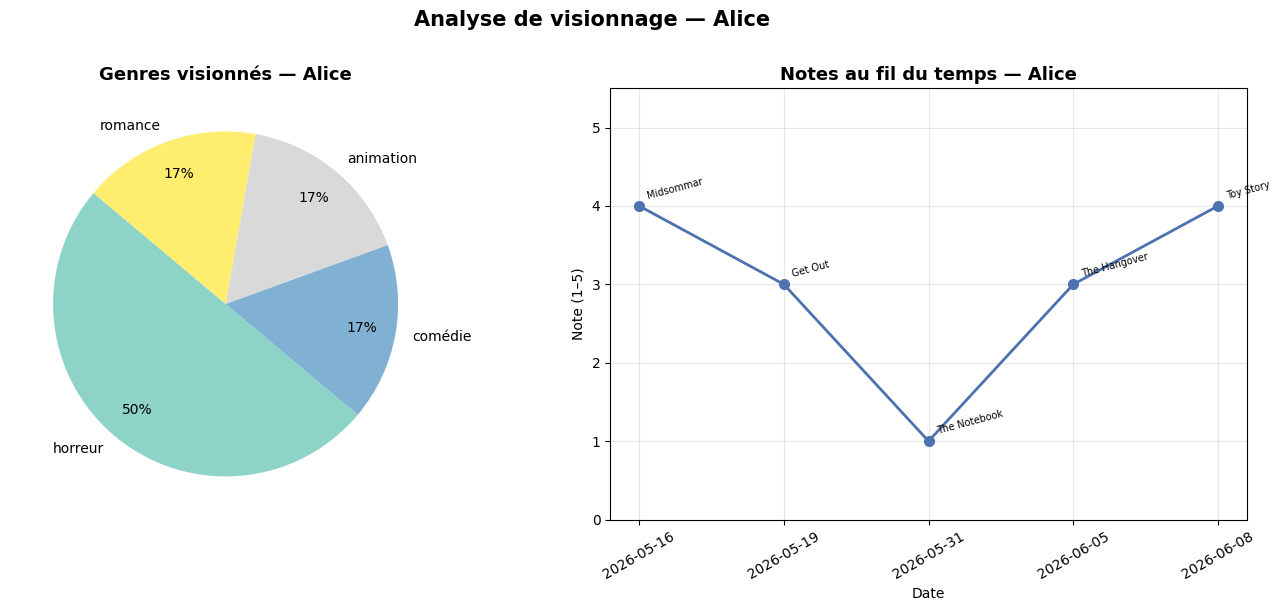

In [29]:
"""
Exercice 3 : Analyse et visualisation
- Diagramme circulaire des genres visionnés
- Graphique linéaire des notes au fil du temps
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime, timedelta
import random

random.seed(42)

GENRES_VALIDES = ["action", "drame", "comédie", "thriller", "sci-fi", "horreur", "romance", "animation"]


# ── Chargement des données ─────────────────────────────────────────────────────
def charger_utilisateurs() -> list:
    try:
        with open("utilisateurs.json", encoding="utf-8") as f:
            return json.load(f)
    except FileNotFoundError:
        print(" Lancez d'abord ex1_simulation_donnees.py")
        exit(1)


# ── Ajout de dates simulées à l'historique ────────────────────────────────────
def ajouter_dates(historique: list) -> list:
    """Attribue des dates aléatoires dans les 30 derniers jours."""
    aujourd_hui = datetime.today()
    for h in historique:
        jours_avant = random.randint(0, 30)
        h["date"] = (aujourd_hui - timedelta(days=jours_avant)).strftime("%Y-%m-%d")
    return sorted(historique, key=lambda x: x["date"])


# ── Visualisation 1 : Diagramme circulaire des genres ─────────────────────────
def pie_genres(utilisateur: dict, ax: plt.Axes):
    # Garder uniquement les genres valides (exclure aberrants)
    genres = [
        h["genre"] for h in utilisateur["watch_history"]
        if h["genre"] in GENRES_VALIDES
    ]

    if not genres:
        ax.set_title(f"Aucun genre valide — {utilisateur['name']}", fontsize=13)
        return

    comptage = Counter(genres)
    labels   = list(comptage.keys())
    valeurs  = list(comptage.values())
    couleurs = plt.cm.Set3(np.linspace(0, 1, len(labels)))

    ax.pie(
        valeurs,
        labels=labels,
        autopct="%1.0f%%",
        colors=couleurs,
        startangle=140,
        pctdistance=0.8,
    )
    ax.set_title(f"Genres visionnés — {utilisateur['name']}", fontsize=13, fontweight="bold")


# ── Visualisation 2 : Notes au fil du temps ───────────────────────────────────
def line_notes(utilisateur: dict, ax: plt.Axes):
    historique = ajouter_dates(utilisateur["watch_history"])

    # Filtrer les notes manquantes (None) et aberrantes (hors [1, 5])
    historique = [
        h for h in historique
        if h["rating"] is not None and 1 <= h["rating"] <= 5
    ]

    if not historique:
        ax.set_title(f"Aucune note valide — {utilisateur['name']}", fontsize=13)
        return

    dates  = [h["date"] for h in historique]
    notes  = [h["rating"] for h in historique]
    titres = [h["movie"] for h in historique]

    ax.plot(dates, notes, marker="o", color="#4C72B0", linewidth=2, markersize=7)

    for d, n, t in zip(dates, notes, titres):
        ax.annotate(t, (d, n), textcoords="offset points", xytext=(5, 5), fontsize=7, rotation=15)

    ax.set_title(f"Notes au fil du temps — {utilisateur['name']}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Note (1–5)")
    ax.set_ylim(0, 5.5)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    utilisateurs = charger_utilisateurs()

    cible = utilisateurs[0]
    print(f" Visualisation pour : {cible['name']}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Analyse de visionnage — {cible['name']}", fontsize=15, fontweight="bold", y=1.01)

    pie_genres(cible, axes[0])
    line_notes(cible, axes[1])

    plt.tight_layout()
    plt.savefig("visualisation.png", dpi=150, bbox_inches="tight")
    print(" Graphiques sauvegardés dans visualisation.png")
    plt.show()